In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("data/raw/churn_dirty.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (10150, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619.0,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608.0,SPAIN,F,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502.0,France,female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699.0,france,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850.0,spain,Female,43.0,2,125510.82,1,1.0,1.0,79084.10,0


In [6]:
df.drop(columns=["RowNumber", "Surname"], inplace=True)
print(f"Columns after drop: {list(df.columns)}")
print(f"Shape: {df.shape}")

Columns after drop: ['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Shape: (10150, 12)


In [8]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)

print(f"Rows before : {before}")
print(f"Rows removed: {before - after}")
print(f"Rows after  : {after}")

Rows before : 10150
Rows removed: 150
Rows after  : 10000


In [9]:
len(df)

10000

In [12]:
# Fix Geography
df["Geography"] = df["Geography"].str.strip().str.title()

# Fix Gender
df["Gender"] = df["Gender"].str.strip().str.title()
df["Gender"] = df["Gender"].replace({
    "M": "Male", "F": "Female"
})

print(f"Geography unique: {sorted(df['Geography'].unique())}")
print(f"Gender unique   : {sorted(df['Gender'].unique())}")

Geography unique: ['France', 'Germany', 'Spain']
Gender unique   : ['Female', 'Male']


In [13]:
before = len(df)

# Age must be between 18 and 100
df = df[(df["Age"].isna()) | ((df["Age"] >= 18) & (df["Age"] <= 100))]

# CreditScore must be between 300 and 850
df = df[(df["CreditScore"].isna()) | ((df["CreditScore"] >= 300) & (df["CreditScore"] <= 850))]

# Salary cannot be negative
df = df[df["EstimatedSalary"] >= 0]

after = len(df)
print(f"Rows removed as outliers: {before - after}")
print(f"Shape after             : {df.shape}")

Rows removed as outliers: 60
Shape after             : (9940, 12)


In [3]:
df.isnull().sum()

RowNumber            0
CustomerId           0
Surname              0
CreditScore        304
Geography            0
Gender               0
Age                504
Tenure               0
Balance            806
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

In [4]:
# CreditScore — normally distributed → use mean
credit_median = round(df["CreditScore"].median(), 0)
df["CreditScore"] = df["CreditScore"].fillna(credit_median)
print(f"CreditScore filled with mean: {credit_median}")

# Age — slightly skewed → use median
age_median = df["Age"].median()
df["Age"] = df["Age"].fillna(age_median)
print(f"Age filled with median      : {age_median}")

# Balance — impute per Geography group (more accurate)
df["Balance"] = df.groupby("Geography")["Balance"].transform(
    lambda x: x.fillna(x.median())
)
print(f"Balance filled with median per Geography group")

# Confirm
print(f"\nRemaining nulls: {df.isnull().sum()}")

CreditScore filled with mean: 652.0
Age filled with median      : 37.0
Balance filled with median per Geography group

Remaining nulls: RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [15]:
df["Age"]            = df["Age"].astype(int)
df["CreditScore"]    = df["CreditScore"].astype(int)
df["HasCrCard"]      = df["HasCrCard"].astype(int)
df["IsActiveMember"] = df["IsActiveMember"].astype(int)
df["Exited"]         = df["Exited"].astype(int)

print(df.dtypes)

CustomerId           int64
CreditScore          int32
Geography           object
Gender              object
Age                  int32
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int32
IsActiveMember       int32
EstimatedSalary    float64
Exited               int32
dtype: object


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'CreditScore'}>],
       [<Axes: title={'center': 'Balance'}>, <Axes: >]], dtype=object)

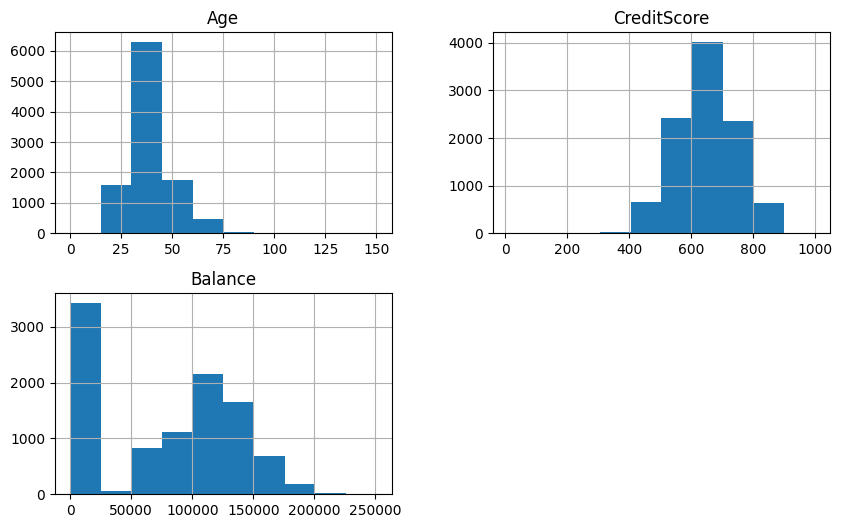

In [5]:
df[["Age", "CreditScore", "Balance"]].describe()
df[["Age", "CreditScore", "Balance"]].hist(figsize=(10, 6))

In [7]:
# Check missing values before imputation
missing_cols = ["Age", "CreditScore", "Balance"]

df[missing_cols].isnull().sum()

df[missing_cols].describe()

,Age,CreditScore,Balance
count,10150.000000,10150.000000,10150.000000
mean,38.933399,650.395369,76620.031638
std,10.968649,97.702456,60659.454470
min,0.000000,10.000000,0.000000
25%,32.000000,586.000000,0.000000
50%,37.000000,652.000000,94219.290000
75%,43.000000,715.000000,125579.852500
max,150.000000,999.000000,250898.090000


In [ ]:
# 1. Zero balance flag
df["zero_balance_flag"] = (df["Balance"] == 0).astype(int)
print(f"Zero balance customers: {df['zero_balance_flag'].sum()}")

# 2. Age group
df["age_group"] = pd.cut(
    df["Age"],
    bins=[17, 30, 50, 100],
    labels=["Young (18-30)", "Mid (31-50)", "Senior (51+)"]
)
print(f"\nAge groups:\n{df['age_group'].value_counts()}")

# 3. Credit score band
df["credit_score_band"] = pd.cut(
    df["CreditScore"],
    bins=[299, 579, 669, 739, 850],
    labels=["Poor", "Fair", "Good", "Excellent"]
)
print(f"\nCredit bands:\n{df['credit_score_band'].value_counts()}")

# 4. Products per tenure
df["products_per_tenure"] = (df["NumOfProducts"] / (df["Tenure"] + 1)).round(3)

# 5. Salary to balance ratio
df["balance_to_salary_ratio"] = (df["Balance"] / (df["EstimatedSalary"] + 1)).round(4)

print(f"\nNew columns added: zero_balance_flag, age_group, credit_score_band, products_per_tenure, salary_to_balance_ratio")
print(f"Final shape: {df.shape}")

Zero balance customers: 3285

Age groups:
Mid (31-50)      6887
Young (18-30)    1864
Senior (51+)     1189
Name: age_group, dtype: int64

Credit bands:
Fair         3519
Good         2347
Poor         2272
Excellent    1802
Name: credit_score_band, dtype: int64

New columns added: zero_balance_flag, age_group, credit_score_band, products_per_tenure, salary_to_balance_ratio
Final shape: (9940, 17)


In [ ]:
print("=" * 45)
print("CLEANING SUMMARY")
print("=" * 45)
print(f"Final shape     : {df.shape}")
print(f"Remaining nulls : {df.isnull().sum().sum()}")
print(f"Columns         : {list(df.columns)}")
print("=" * 45)

df.to_csv("data/processed/churn_clean.csv", index=False)
print("\nchurn_clean.csv saved to data/processed/")

CLEANING SUMMARY
Final shape     : (9940, 17)
Remaining nulls : 0
Columns         : ['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'zero_balance_flag', 'age_group', 'credit_score_band', 'products_per_tenure', 'salary_to_balance_ratio']

churn_clean.csv saved to data/processed/


In [4]:
print(credit_mean)

650.0
